# Cluster 1

In [1]:
# ============================================
# 0) Shared imports
# ============================================
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

import c1_forecasting
importlib.reload(c1_forecasting)
from c1_forecasting import run_c1_forecasting_2

import c3_forecasting
importlib.reload(c3_forecasting)
from c3_forecasting import run_c3_forecasting_2

import c1c3_analysis
importlib.reload(c1c3_analysis)
from c1c3_analysis import run_cluster_analysis


def period_metric_pivot(metrics_by_period: pd.DataFrame, metric_col: str):
    pivot = metrics_by_period.pivot(index="method", columns="period", values=metric_col)

    def _period_key(label):
        label = str(label)
        if label.startswith("P") and label[1:].isdigit():
            return (0, int(label[1:]))
        return (1, label)

    return pivot.reindex(sorted(pivot.columns, key=_period_key), axis=1)

In [2]:
# ============================================
# 1) Run C1 pipeline and display standardized outputs
# ============================================
art_c1 = run_c1_forecasting_2(
    train_path="data/forecasting/train_daily.parquet",
    test_path="data/forecasting/test_daily.parquet",
    cluster_id=1,
    n_periods=4,
    eps_mape=1.0,
    metric_name="bounded_mape",
    zinb_threshold=0.5,
    tune=False,
    tuning_objective="wmape",
    save_predictions=True,
    prediction_output_path="data/forecasting/c1_prediction.parquet",
)

print("C1 prediction file:", art_c1.prediction_output_path)
print("\n=== C1 Summary Metrics ===")
display(art_c1.metrics_overall[[
    "method",
    "WMAPE_0_100",
    "EPSILON_MAPE_PCT",
    "NON_ZERO_MAPE_PCT",
    "pred_nonzero_rate",
    "actual_nonzero_rate",
]])

print("\n=== C1 WMAPE by Period ===")
display(period_metric_pivot(art_c1.metrics_by_period, "WMAPE_0_100"))

print("\n=== C1 Epsilon-MAPE by Period ===")
display(period_metric_pivot(art_c1.metrics_by_period, "EPSILON_MAPE_PCT"))

print("\n=== C1 Non-Zero MAPE by Period ===")
display(period_metric_pivot(art_c1.metrics_by_period, "NON_ZERO_MAPE_PCT"))

print("\n=== C1 Best Parameters ===")
display(pd.DataFrame([art_c1.tuning_best_config]))

print("\n=== C1 Metadata ===")
display(pd.DataFrame([art_c1.metadata]))

c:\Softwares\miniconda3\envs\forecasting-retail\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C1 prediction file: data\forecasting\c1_prediction.parquet

=== C1 Summary Metrics ===


,method,WMAPE_0_100,EPSILON_MAPE_PCT,NON_ZERO_MAPE_PCT,pred_nonzero_rate,actual_nonzero_rate
0,zinb,126.093477,173.054525,160.763760,0.031461,0.25482
1,naive7,122.762082,350.963586,151.673993,0.202731,0.25482



=== C1 WMAPE by Period ===


period,P1,P2,P3,P4
method,,,,
naive7,139.728981,140.13876,120.705908,110.088345
zinb,96.523619,135.71370,158.071288,111.299685


...

period,P1,P2,P3,P4
method,,,,
naive7,180.511150,163.836328,147.499692,128.647374
zinb,116.089363,156.283354,223.879982,139.528760



=== C1 Best Parameters ===


,zinb_threshold,clip_q,clip_max_cap,search_holdout_days,maxiter,score,fit_status,tuning_objective
0,0.5,0.98,200,0,200,NaN,fixed_optimal_params_tuning_disabled,wmape



=== C1 Metadata ===


,cluster_id,train_path,test_path,train_rows,test_rows,n_periods,metric_name,eps_mape,zinb_threshold,zinb_status,tune,tuning_objective,search_holdout_days,clip_q,clip_max_cap,split_policy,baseline_col,model_col
0,1,data/forecasting/train_daily.parquet,data/forecasting/test_daily.parquet,39366,22658,4,bounded_mape,1.0,0.5,ok,False,wmape,0,0.98,200,strict parquet train/test only; tune disabled ...,pred_naive7,pred_zinb


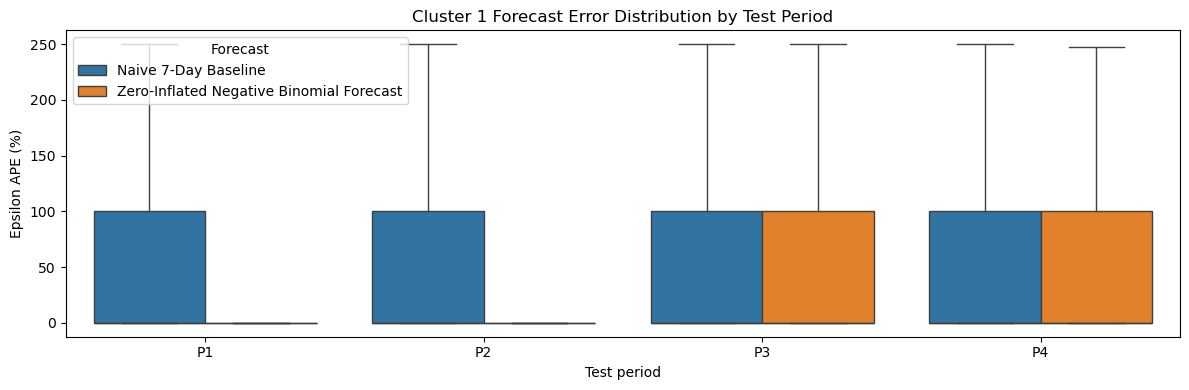

In [3]:
# ============================================
# 2) C1 epsilon-APE boxplot by period
# ============================================
c1_box_df = art_c1.ape_box_df.copy()
c1_box_df["method"] = c1_box_df["method"].map({
    "naive7": "Naive 7-Day Baseline",
    "zinb": "Zero-Inflated Negative Binomial Forecast",
}).fillna(c1_box_df["method"])

output_dir = Path("images/c1_results")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 4))
sns.boxplot(
    data=c1_box_df,
    x="period",
    y="APE_EPS_PCT",
    hue="method",
    showfliers=False,
)
plt.title("Cluster 1 Forecast Error Distribution by Test Period")
plt.ylabel("Epsilon APE (%)")
plt.xlabel("Test period")
plt.legend(title="Forecast")
plt.tight_layout()
plt.savefig("images/c1_results/c1_error_boxplot_by_period.svg", format="svg", bbox_inches="tight")
plt.show()

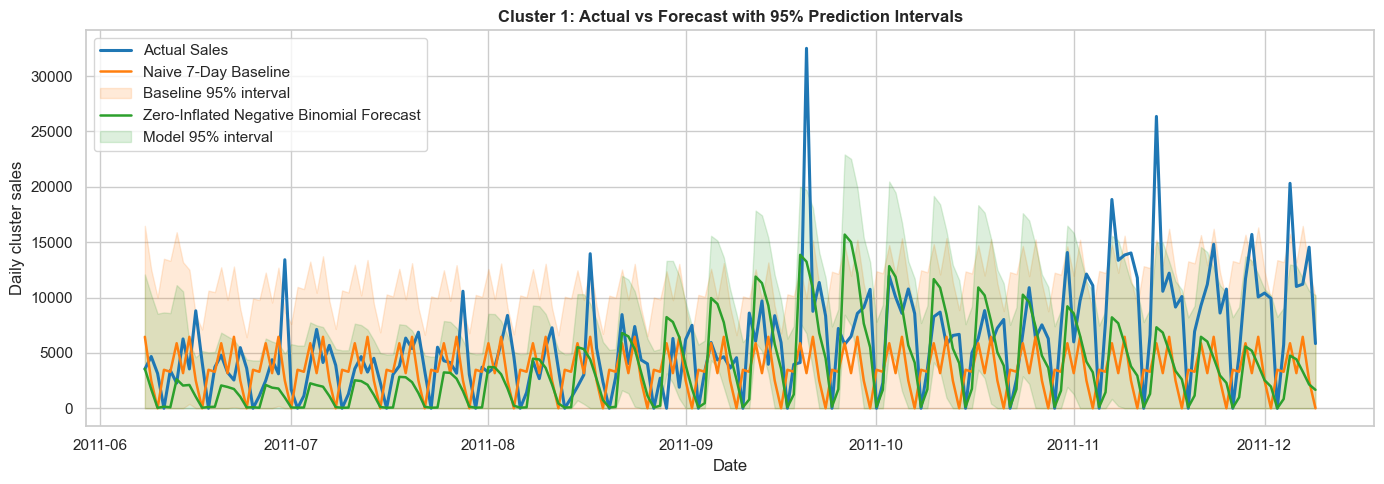

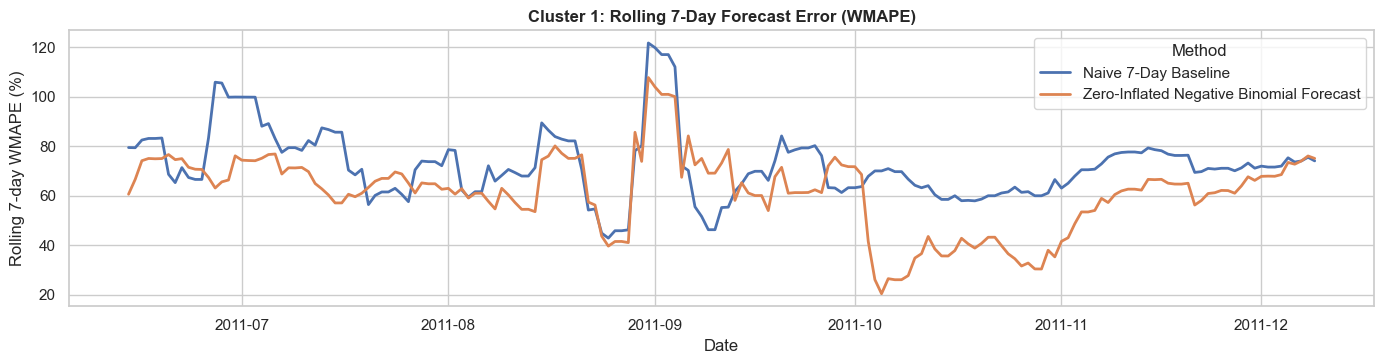

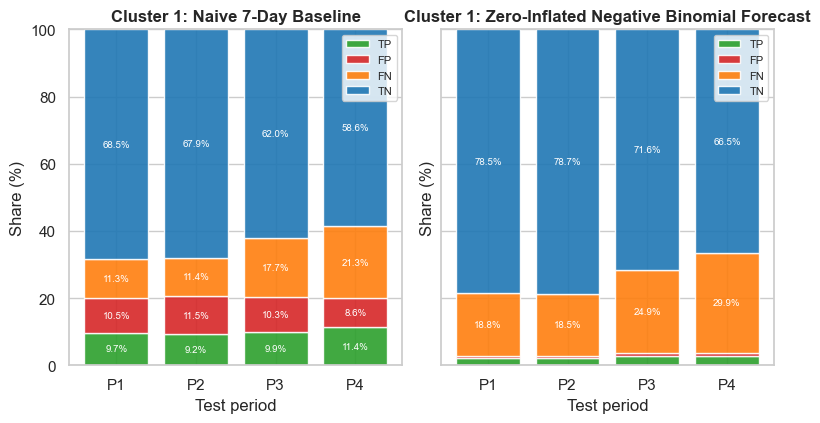

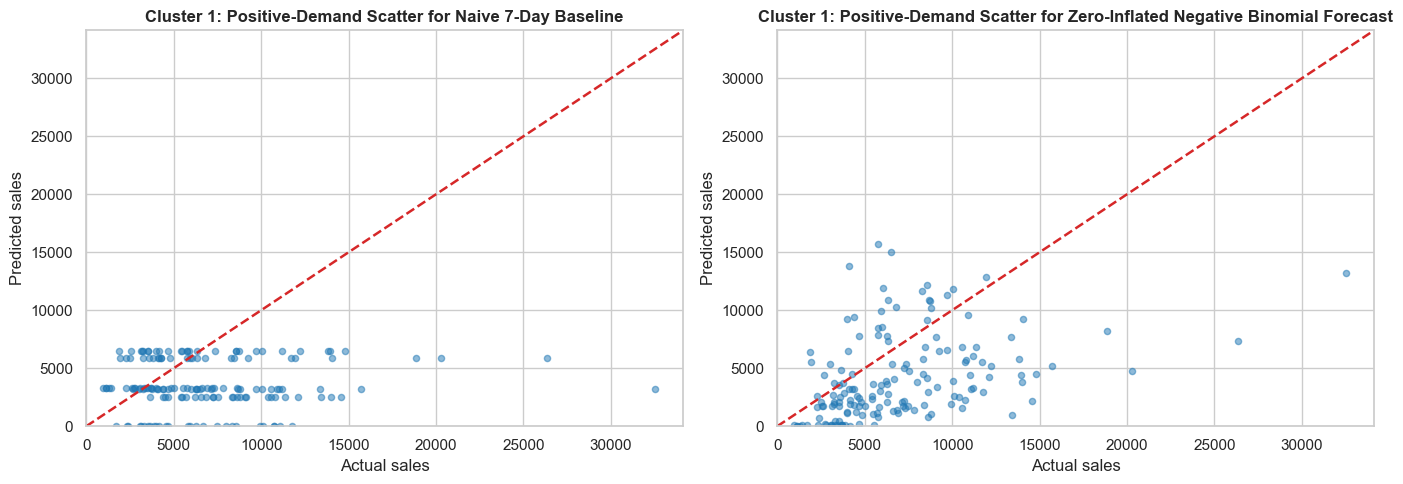

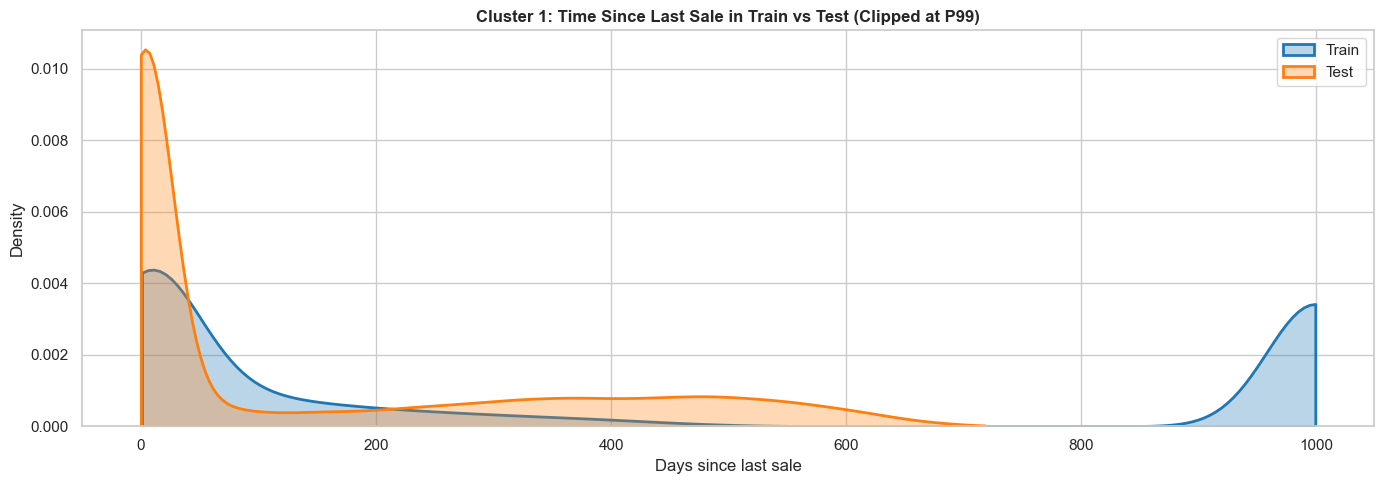

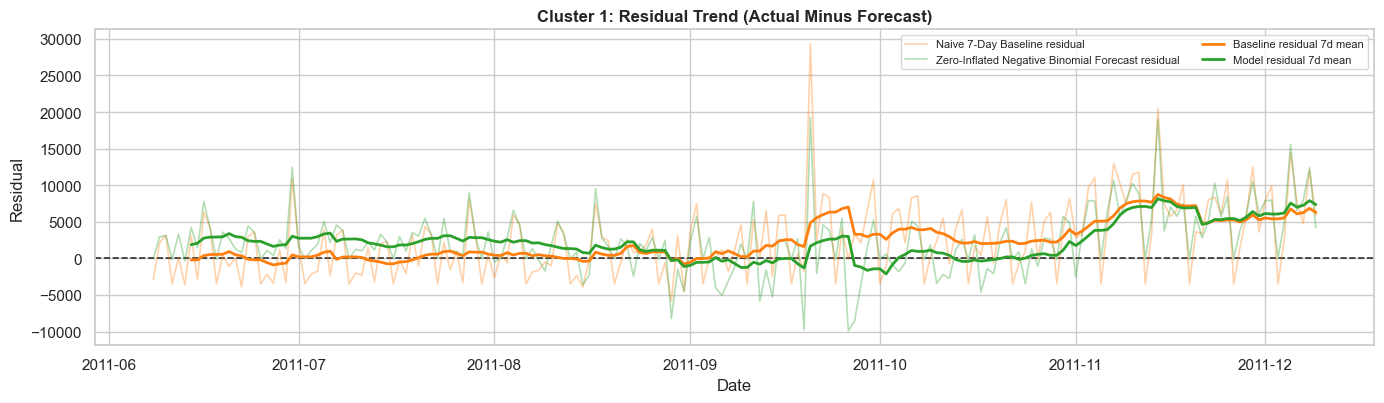

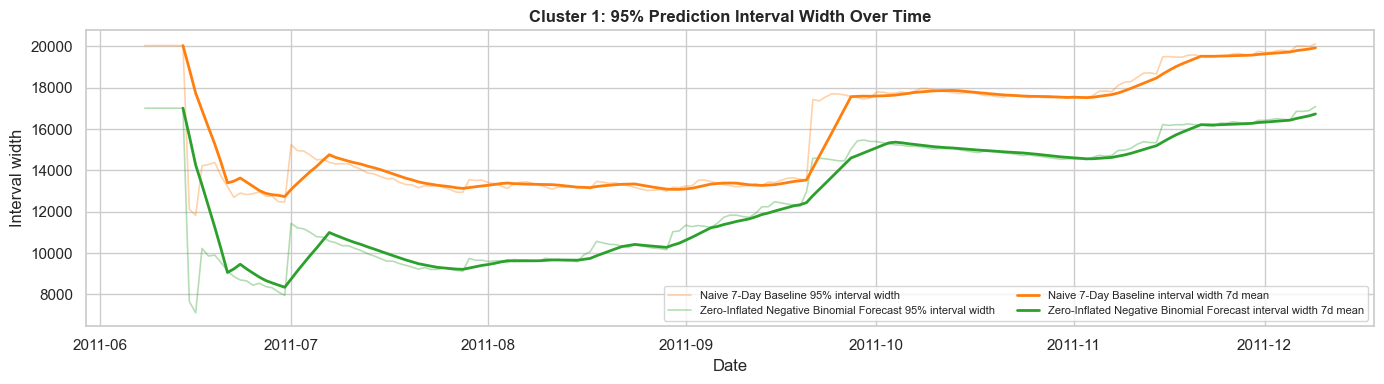

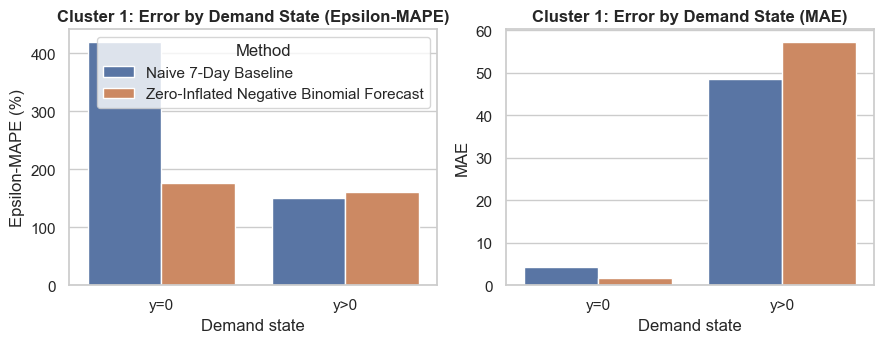

,method_display,wmape_pct,epsilon_mape_pct,non_zero_mape_pct,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap
0,Naive 7-Day Baseline,122.762082,350.963586,151.673993,0.202731,0.25482,-0.052088
1,Zero-Inflated Negative Binomial Forecast,126.093477,173.054525,160.763760,0.031461,0.25482,-0.223359


,method,period,TP,FP,FN,TN,method_display,TP_pct,FP_pct,FN_pct,TN_pct
0,baseline,P1,2153,2326,2519,15233,Naive 7-Day Baseline,9.684675,10.462867,11.331024,68.521434
1,baseline,P2,2004,2495,2475,14784,Naive 7-Day Baseline,9.210405,11.467047,11.375126,67.947422
2,baseline,P3,2162,2243,3860,13493,Naive 7-Day Baseline,9.936575,10.308852,17.740601,62.013972
3,baseline,P4,2481,1876,4644,12757,Naive 7-Day Baseline,11.402702,8.622116,21.343874,58.631308
4,model,P1,492,105,4180,17454,Zero-Inflated Negative Binomial Forecast,2.213126,0.472313,18.802573,78.511988
5,model,P2,455,157,4024,17122,Zero-Inflated Negative Binomial Forecast,2.091185,0.721574,18.494347,78.692895
6,model,P3,611,151,5411,15585,Zero-Inflated Negative Binomial Forecast,2.808163,0.693998,24.869014,71.628826
7,model,P4,619,163,6506,14470,Zero-Inflated Negative Binomial Forecast,2.844931,0.749150,29.901645,66.504274


,method,state,count,epsilon_mape_pct,wmape_pct,mae,method_display
0,baseline,y=0,64930,419.707516,2.725161e+07,4.197075,Naive 7-Day Baseline
1,baseline,y>0,22298,150.365506,9.784801e+01,48.598283,Naive 7-Day Baseline
2,model,y=0,64930,176.667389,1.147101e+07,1.766674,Zero-Inflated Negative Binomial Forecast
3,model,y>0,22298,160.237345,1.154328e+02,57.332137,Zero-Inflated Negative Binomial Forecast


,train_mean,test_mean,train_p90,test_p90,train_999_share,test_999_share
0,394.264857,141.387258,999.0,489.0,0.354064,0.0


In [4]:
# ============================================
# 3) c1c3_analysis standard diagnostics for C1
# ============================================
c1_results = run_cluster_analysis(
    art=art_c1,
    cluster_tag="c1",
    cluster_label="Cluster 1",
    baseline_col="pred_naive7",
    model_col="pred_zinb",
    baseline_name="Naive 7-Day Baseline",
    model_name="Zero-Inflated Negative Binomial Forecast",
    actual_name="Actual Sales",
    target_label="Daily cluster sales",
    rolling_metric="wmape",
    rolling_window=7,
    eps=1.0,
    n_periods=4,
    save_svg=True,
    output_dir="images/c1_results",
)

display(c1_results["metric_table"][[
    "method_display",
    "wmape_pct",
    "epsilon_mape_pct",
    "non_zero_mape_pct",
    "pred_nonzero_rate",
    "actual_nonzero_rate",
    "nonzero_rate_gap",
]])
display(c1_results["confusion_by_period"])
display(c1_results["error_decomposition"])
display(c1_results["distribution_shift_stats"])

# Cluster 3

In [5]:
# ============================================
# 4) Cluster 3 uses the same shared imports and metric helpers above
# ============================================

In [6]:
# ============================================
# 5) Run C3 pipeline and display standardized outputs
# ============================================
art_c3 = run_c3_forecasting_2(
    train_path="data/forecasting/train_daily.parquet",
    test_path="data/forecasting/test_daily.parquet",
    cluster_id=3,
    n_periods=4,
    eps_mape=1.0,
    metric_name="bounded_mape",
    tuning_objective="wmape",
    search_enabled=False,
    save_predictions=True,
    prediction_output_path="data/forecasting/c3_prediction.parquet",
    lognormal_correction=True,
)

print("C3 prediction file:", art_c3.prediction_output_path)
print("\n=== C3 Summary Metrics ===")
display(art_c3.metrics_overall[[
    "method",
    "WMAPE_0_100",
    "EPSILON_MAPE_PCT",
    "NON_ZERO_MAPE_PCT",
    "pred_nonzero_rate",
    "actual_nonzero_rate",
]])

print("\n=== C3 WMAPE by Period ===")
display(period_metric_pivot(art_c3.metrics_by_period, "WMAPE_0_100"))

print("\n=== C3 Epsilon-MAPE by Period ===")
display(period_metric_pivot(art_c3.metrics_by_period, "EPSILON_MAPE_PCT"))

print("\n=== C3 Non-Zero MAPE by Period ===")
display(period_metric_pivot(art_c3.metrics_by_period, "NON_ZERO_MAPE_PCT"))

print("\n=== C3 Best Parameters ===")
display(pd.DataFrame([art_c3.tuning_best_config]))

if art_c3.tuning_trials is not None:
    print("\n=== C3 Tuning Trials ===")
    display(art_c3.tuning_trials)

print("\n=== C3 Metadata ===")
display(pd.DataFrame([art_c3.metadata]))

C3 prediction file: data/forecasting/c3_prediction.parquet

=== C3 Summary Metrics ===


,method,WMAPE_0_100,EPSILON_MAPE_PCT,NON_ZERO_MAPE_PCT,pred_nonzero_rate,actual_nonzero_rate
0,baseline,165.972244,125.826621,131.433162,0.076648,0.089202
1,model,150.113819,112.197055,154.436082,0.129682,0.089202



=== C3 WMAPE by Period ===


period,P1,P2,P3,P4
method,,,,
baseline,177.836615,209.050388,164.424551,141.735670
model,130.134085,181.565921,154.590754,144.280935



=== C3 Epsilon-MAPE by Period ===


...

period,P1,P2,P3,P4
method,,,,
baseline,133.251992,143.294972,129.082083,125.452569
model,117.270262,155.986569,164.362963,172.935975



=== C3 Best Parameters ===


,clf_max_depth,clf_l2,reg_max_depth,reg_l2,min_samples_leaf,lognormal_correction,occurrence_threshold,prediction_floor,seasonal_anchor_weight
0,5,1.0,5,1.0,20,True,0.2,0.0,0.4



=== C3 Metadata ===


,cluster_id,n_train_skus,n_test_skus,train_rows,test_rows,train_start,train_end,test_start,test_end,train_nonzero_rate,...,prediction_floor,seasonal_anchor_weight,search_enabled,search_holdout_days,metric_name,tuning_objective,eps_mape,baseline_col,model_col,split_policy
0,3,1017,1017,564435,188145,2009-12-01,2011-06-08,2011-06-08,2011-12-09,0.106446,...,0.0,0.4,False,None,bounded_mape,wmape,1.0,pred_naive7,pred_two_stage,strict parquet train/test for final reporting;...


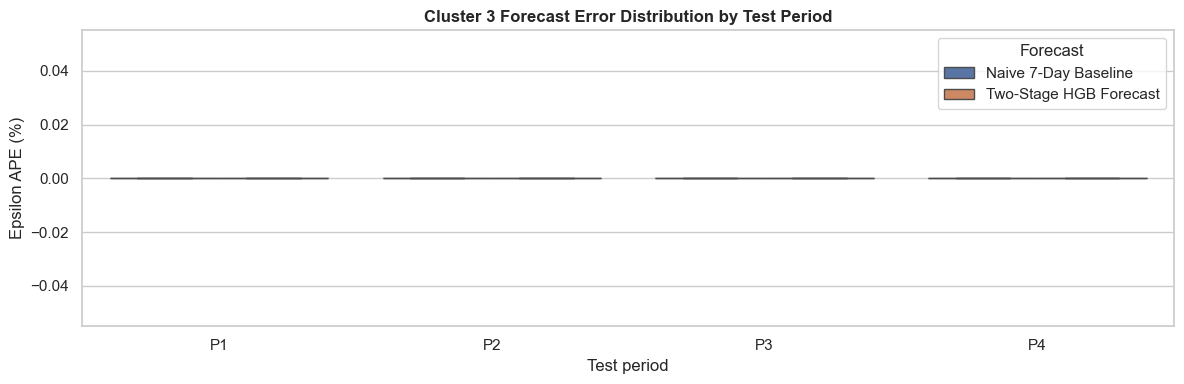

In [8]:
# ============================================
# 6) C3 epsilon-APE boxplot by period
# ============================================
c3_box_df = art_c3.ape_box_df.copy()
c3_box_df["method"] = c3_box_df["method"].map({
    "baseline": "Naive 7-Day Baseline",
    "model": "Two-Stage HGB Forecast",
}).fillna(c3_box_df["method"])

output_dir = Path("images/c3_results")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 4))
sns.boxplot(
    data=c3_box_df,
    x="period",
    y="APE_EPS_PCT",
    hue="method",
    showfliers=False,
)
plt.title("Cluster 3 Forecast Error Distribution by Test Period")
plt.ylabel("Epsilon APE (%)")
plt.xlabel("Test period")
plt.legend(title="Forecast")
plt.tight_layout()
plt.savefig("images/c3_results/c3_error_boxplot_by_period.svg", format="svg", bbox_inches="tight")
plt.show()

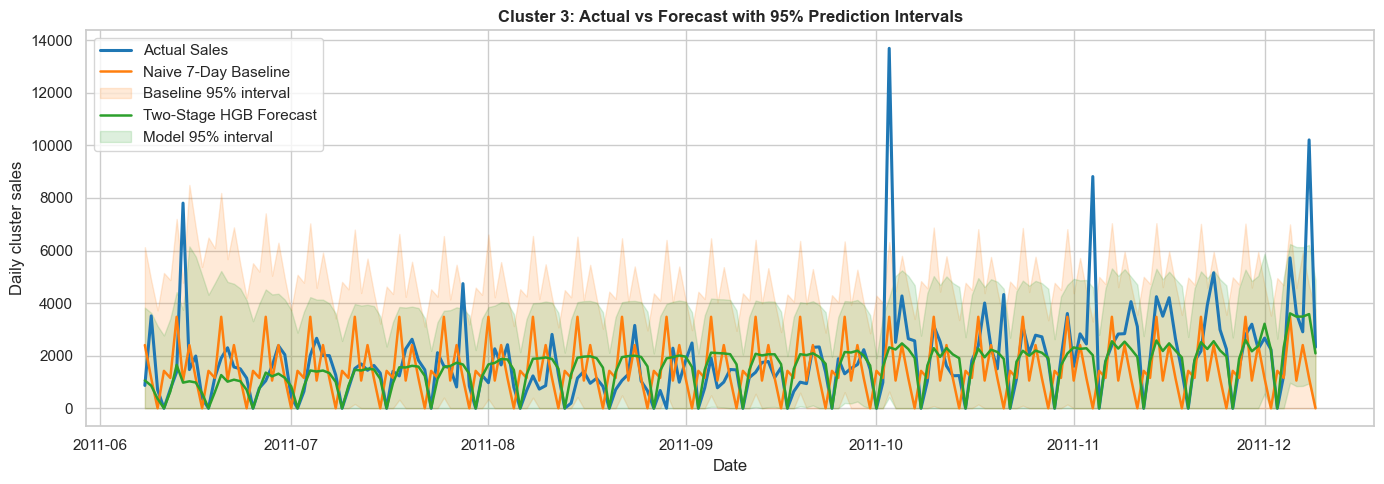

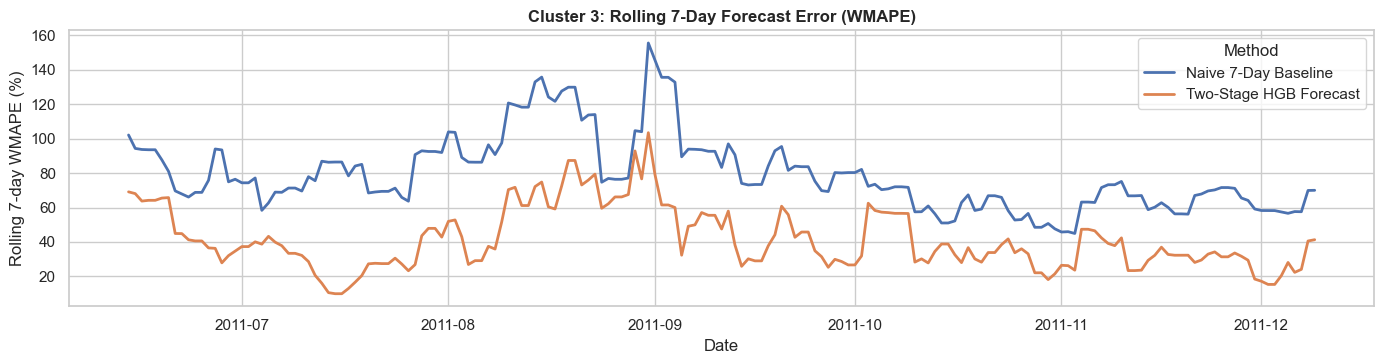

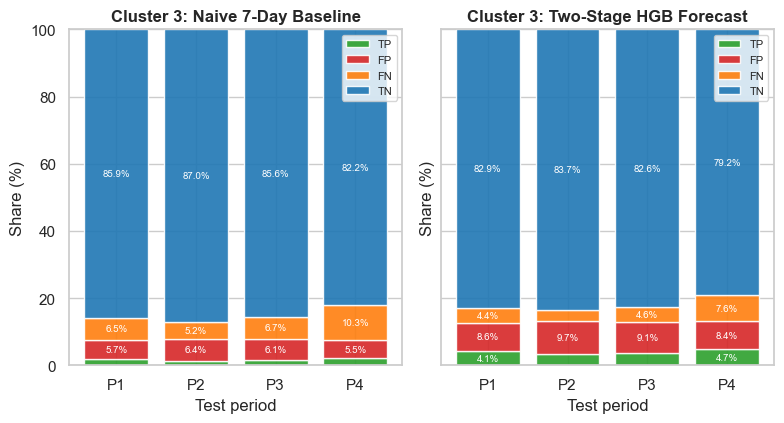

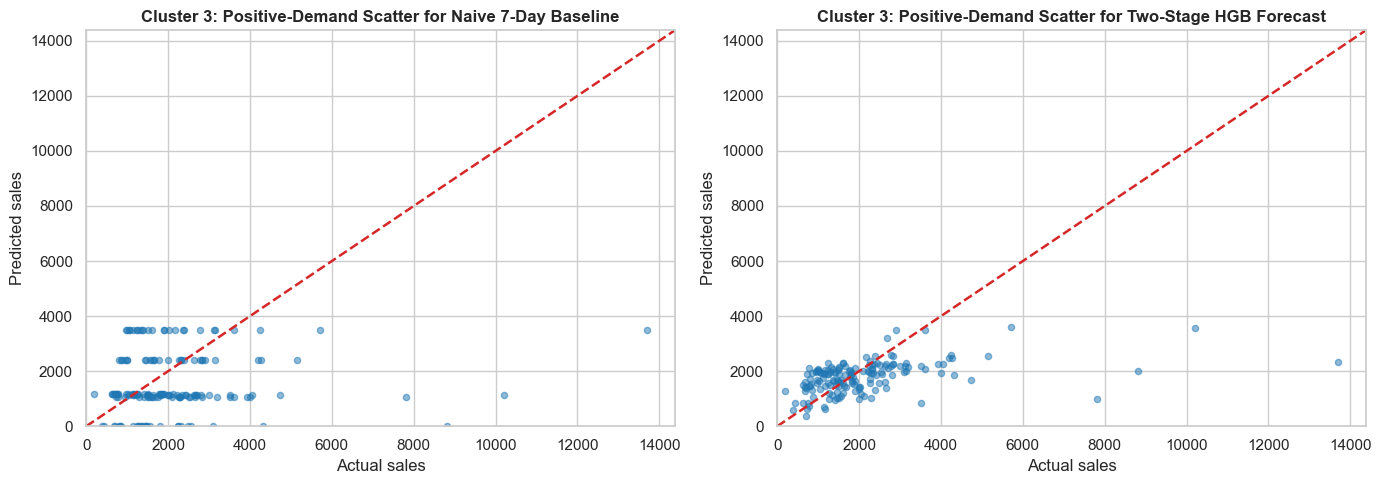

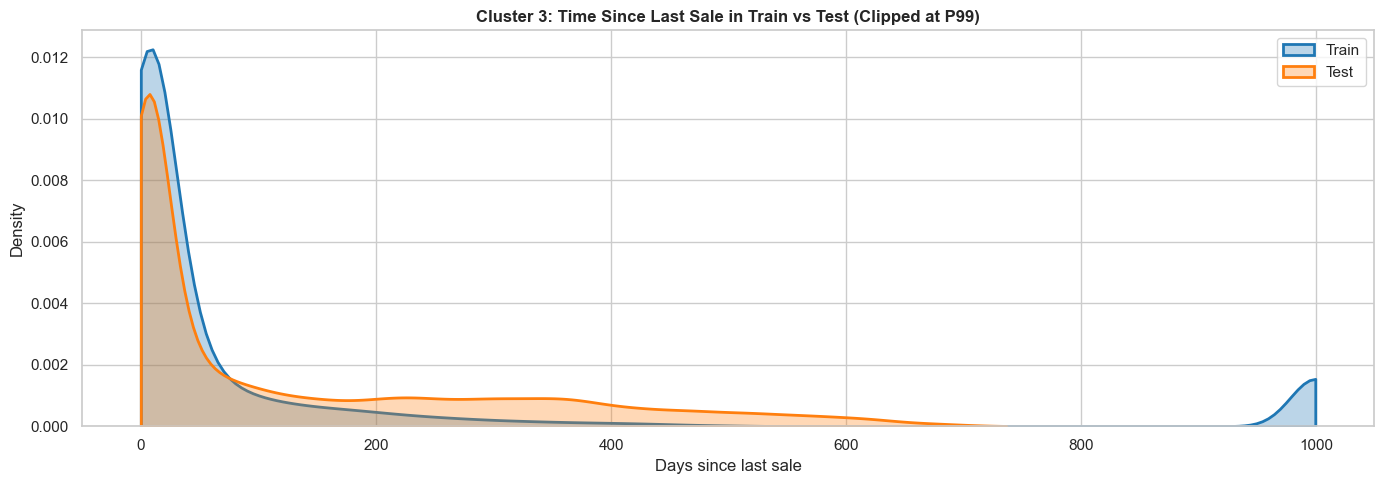

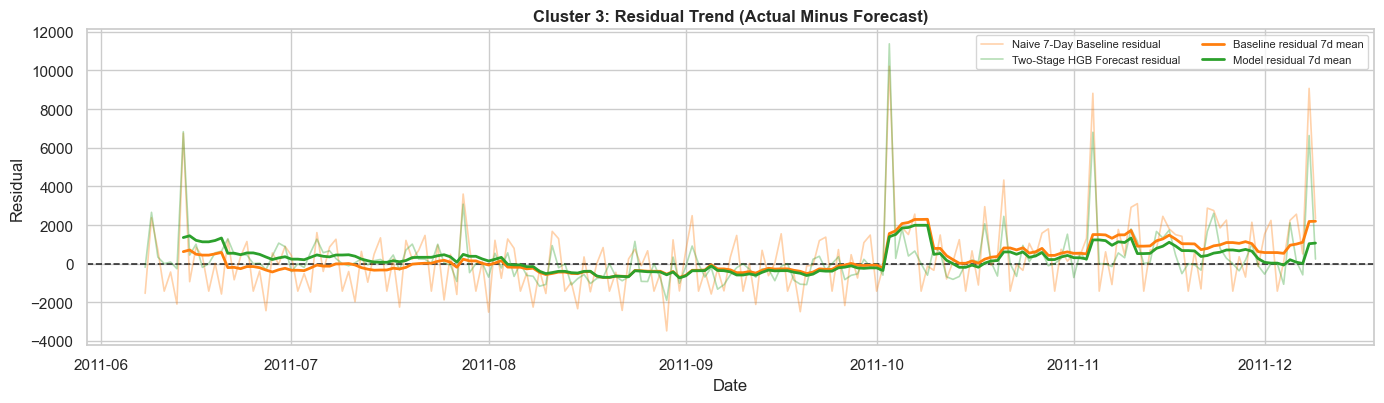

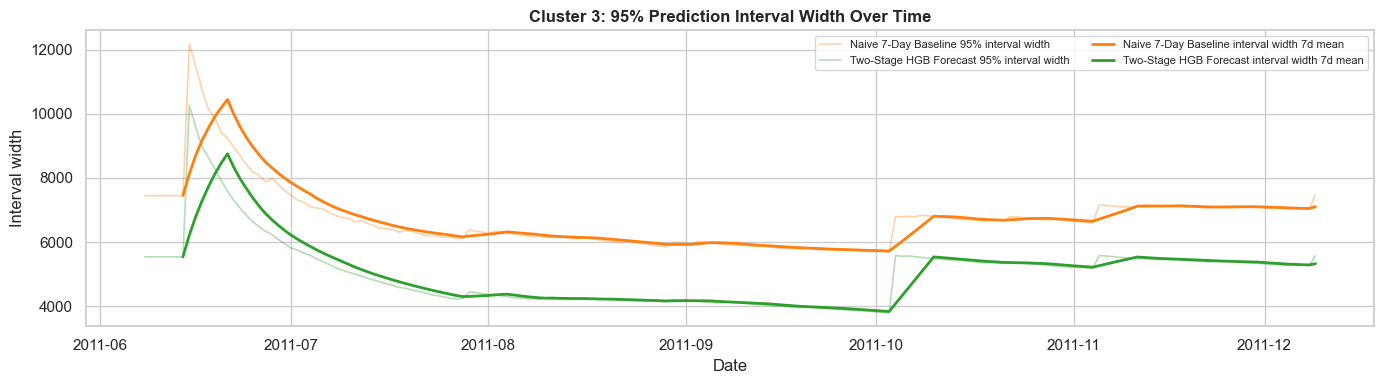

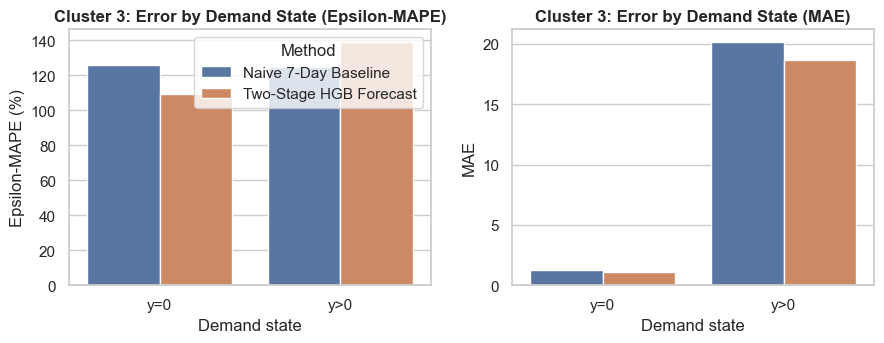

,method_display,wmape_pct,epsilon_mape_pct,non_zero_mape_pct,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap
0,Two-Stage HGB Forecast,150.113819,112.197055,154.436082,0.129682,0.089202,0.040479
1,Naive 7-Day Baseline,165.972244,125.826621,131.433162,0.076648,0.089202,-0.012554


,method,period,TP,FP,FN,TN,method_display,TP_pct,FP_pct,FN_pct,TN_pct
0,baseline,P1,934,2704,3111,41050,Naive 7-Day Baseline,1.954016,5.657022,6.508504,85.880458
1,baseline,P2,647,3012,2419,40704,Naive 7-Day Baseline,1.383011,6.438374,5.170792,87.007824
2,baseline,P3,742,2869,3148,40023,Naive 7-Day Baseline,1.586080,6.132701,6.729084,85.552135
3,baseline,P4,962,2551,4820,38449,Naive 7-Day Baseline,2.056346,5.452952,10.303108,82.187594
4,model,P1,1963,4110,2082,39644,Two-Stage HGB Forecast,4.106780,8.598506,4.355740,82.938974
5,model,P2,1603,4557,1463,39159,Two-Stage HGB Forecast,3.426532,9.740926,3.127271,83.705271
6,model,P3,1747,4259,2143,38633,Two-Stage HGB Forecast,3.734342,9.103929,4.580822,82.580907
7,model,P4,2214,3946,3568,37054,Two-Stage HGB Forecast,4.732589,8.434868,7.626865,79.205677


,method,state,count,epsilon_mape_pct,wmape_pct,mae,method_display
0,baseline,y=0,171362,125.936072,2.158066e+07,1.259361,Naive 7-Day Baseline
1,baseline,y>0,16783,124.709079,1.013854e+02,20.184884,Naive 7-Day Baseline
2,model,y=0,171362,109.548411,1.877243e+07,1.095484,Two-Stage HGB Forecast
3,model,y>0,16783,139.240903,9.393144e+01,18.700874,Two-Stage HGB Forecast


,train_mean,test_mean,train_p90,test_p90,train_999_share,test_999_share
0,119.117578,133.517213,319.0,414.0,0.081823,0.0


In [9]:
# ============================================
# 7) c1c3_analysis standard diagnostics for C3
# ============================================
c3_results = run_cluster_analysis(
    art=art_c3,
    cluster_tag="c3",
    cluster_label="Cluster 3",
    baseline_col="pred_naive7",
    model_col="pred_two_stage",
    baseline_name="Naive 7-Day Baseline",
    model_name="Two-Stage HGB Forecast",
    actual_name="Actual Sales",
    target_label="Daily cluster sales",
    rolling_metric="wmape",
    rolling_window=7,
    eps=1.0,
    n_periods=4,
    save_svg=True,
    output_dir="images/c3_results",
)

display(c3_results["metric_table"][[
    "method_display",
    "wmape_pct",
    "epsilon_mape_pct",
    "non_zero_mape_pct",
    "pred_nonzero_rate",
    "actual_nonzero_rate",
    "nonzero_rate_gap",
]])
display(c3_results["confusion_by_period"])
display(c3_results["error_decomposition"])
display(c3_results["distribution_shift_stats"])